In [1]:
!pip install -q wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.8 MB/s eta 0:00:00


In [2]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
record = wfdb.rdrecord("100", pn_dir="mitdb")
annotation = wfdb.rdann("100", "atr", pn_dir="mitdb")

signal = record.p_signal[:, 0]
fs = record.fs

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", fs, "Hz")
print("Number of annotations:", len(annotation.sample))

Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Number of annotations: 2274


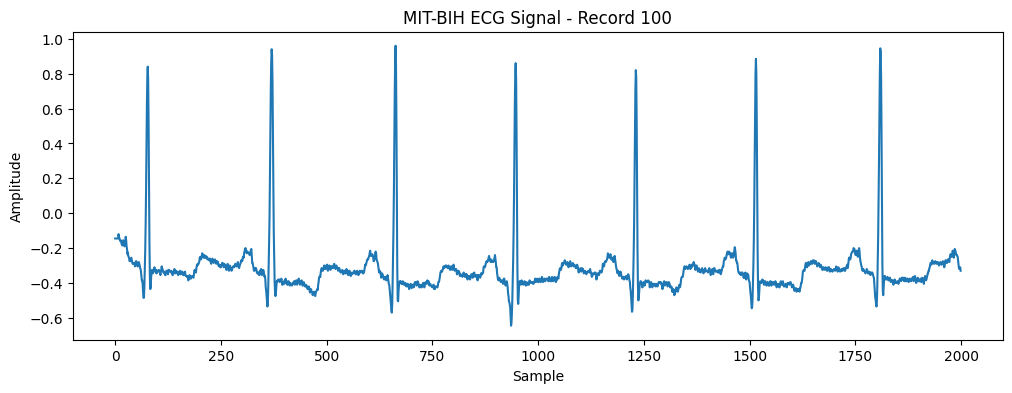

In [4]:
plt.figure(figsize=(12,4))

plt.plot(signal[:2000])

plt.title("MIT-BIH ECG Signal - Record 100")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [5]:
from scipy.signal import butter, filtfilt

lowcut = 0.5
highcut = 40

b, a = butter(
    4,
    [lowcut/(fs/2), highcut/(fs/2)],
    btype="band"
)

filtered_signal = filtfilt(b, a, signal)

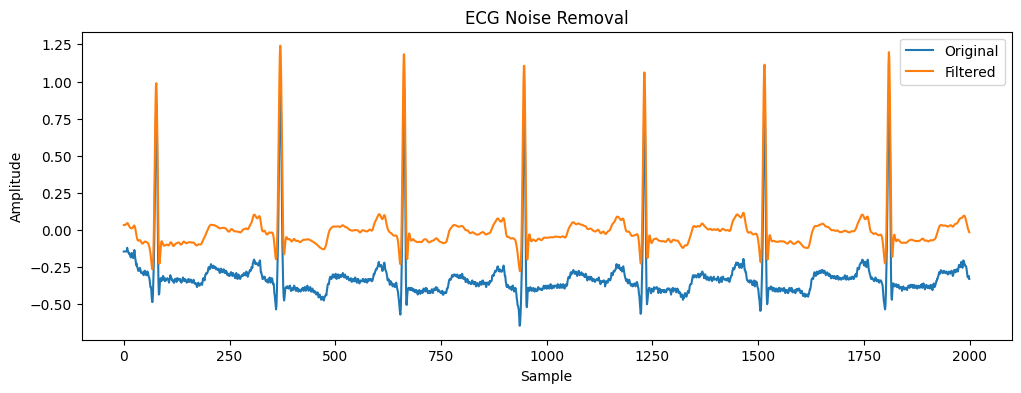

In [6]:
plt.figure(figsize=(12,4))

plt.plot(signal[:2000], label="Original")
plt.plot(filtered_signal[:2000], label="Filtered")

plt.title("ECG Noise Removal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

In [7]:
window_size = int(5 * fs)

windows = np.array([
    filtered_signal[i:i+window_size]
    for i in range(
        0,
        len(filtered_signal) - window_size,
        window_size
    )
])

print("Number of windows:", len(windows))
print("Window shape:", windows.shape)

Number of windows: 361
Window shape: (361, 1800)


In [8]:
features = pd.DataFrame({
    "mean": windows.mean(axis=1),
    "std": windows.std(axis=1),
    "min": windows.min(axis=1),
    "max": windows.max(axis=1),
    "energy": np.mean(windows**2, axis=1)
})

features.head()

,mean,std,min,max,energy
0,-0.003194,0.159633,-0.278717,1.240993,0.025493
1,0.002878,0.170659,-0.242458,1.198003,0.029133
2,-0.001033,0.157981,-0.256442,1.168682,0.024959
3,-0.001912,0.168449,-0.245797,1.258394,0.028379
4,0.000060,0.170082,-0.261643,1.316599,0.028928


In [9]:
features.to_csv(
    "mitbih_ecg_features.csv",
    index=False
)

print("ECG processing complete!")

ECG processing complete!


In [11]:
features.to_csv("mitbih_ecg_features.csv", index=False)

ecg_csv = pd.read_csv("mitbih_ecg_features.csv")

print("ECG Processing CSV:")
display(ecg_csv)

print("\nShape:", ecg_csv.shape)

ECG Processing CSV:


,mean,std,min,max,energy
0,-0.003194,0.159633,-0.278717,1.240993,0.025493
1,0.002878,0.170659,-0.242458,1.198003,0.029133
2,-0.001033,0.157981,-0.256442,1.168682,0.024959
3,-0.001912,0.168449,-0.245797,1.258394,0.028379
4,0.000060,0.170082,-0.261643,1.316599,0.028928
...,...,...,...,...,...
356,0.001568,0.180132,-0.273688,1.347611,0.032450
357,-0.001804,0.200015,-0.294272,1.462600,0.040009
358,0.002549,0.181522,-0.299074,1.320770,0.032957
359,-0.000593,0.202182,-0.304264,1.632970,0.040878



Shape: (361, 5)
